In [2]:
!pip install tensorflow keras matplotlib numpy

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
# from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2042s 12us/step


Training Image:  (50000, 32, 32, 3)
Testing Image:  (10000, 32, 32, 3)


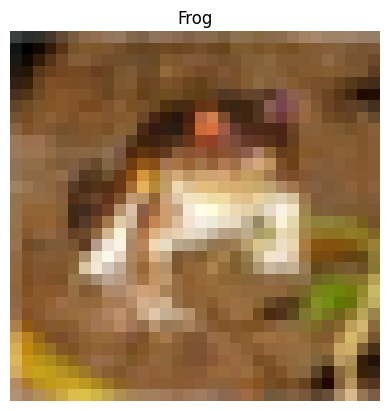

In [7]:
print("Training Image: ",X_train.shape)
print("Testing Image: ",X_test.shape)

class_name =  ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

plt.imshow(X_train[0])
plt.title(class_name[y_train[0][0]])
plt.axis("off")
plt.show()

In [8]:
# normalize dataset
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [9]:
#create CNN model
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3))) # Corrected input_shape for CIFAR-10 (3 color channels)
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
#compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
#train model
history= model.fit(X_train, y_train, epochs = 10, batch_size = 64, validation_split = 0.2)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4177 - loss: 1.6151 - val_accuracy: 0.5157 - val_loss: 1.3636
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5436 - loss: 1.2867 - val_accuracy: 0.5584 - val_loss: 1.2505
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5920 - loss: 1.1532 - val_accuracy: 0.5886 - val_loss: 1.1774
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6316 - loss: 1.0527 - val_accuracy: 0.6273 - val_loss: 1.0863
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6616 - loss: 0.9762 - val_accuracy: 0.6456 - val_loss: 1.0338
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6791 - loss: 0.9204 - val_accuracy: 0.6642 - val_loss: 0.9891
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6966 - loss: 0.8792 - val_accuracy: 0.6520 - val_loss: 1.0204
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7098 - loss: 0.8344 - val_accuracy: 0.

In [12]:
#make prediction
prediction = model.predict(X_test)
predicted_class = np.argmax(prediction, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [13]:
#accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print("Loss: ", loss)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6788 - loss: 0.9535
Loss:  0.953469455242157
Accuracy:  0.6787999868392944


In [14]:
#display prediction
print("predicted class")
print(class_name[predicted_class[0]])
print()
print("actual class")
print(class_name[y_test[0][0]])

predicted class
Cat

actual class
Cat


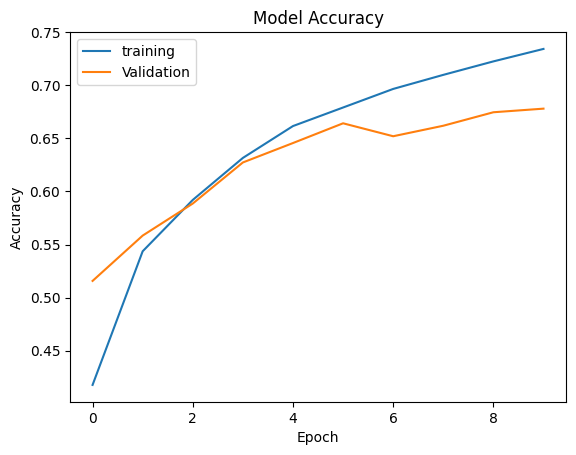

In [15]:
#plot accuracy graph
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.title("Model Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(["training","Validation"])
plt.show()


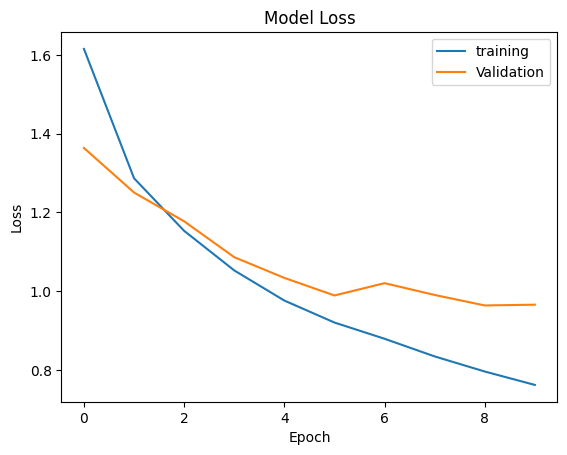

In [16]:
# LOSS graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(["training","Validation"])
plt.show()